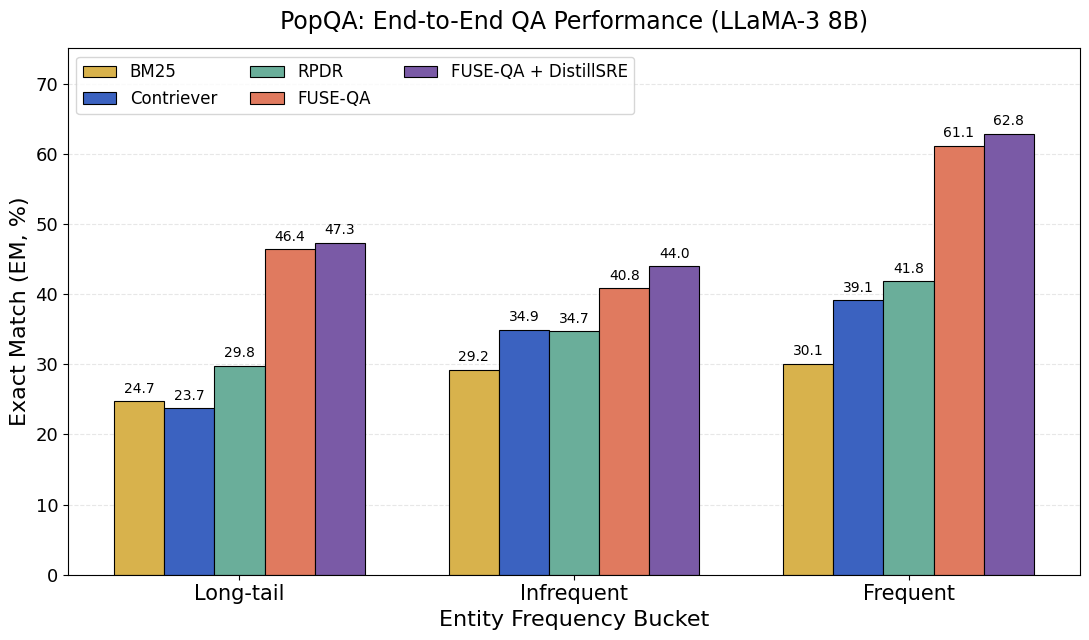

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Data from the paper
# PopQA / LLaMA-3 8B / EM (%)
# -----------------------------
groups = ["Long-tail", "Infrequent", "Frequent"]

bm25 = [24.70, 29.20, 30.10]
contriever = [23.70, 34.90, 39.10]
rpdr = [29.80, 34.70, 41.80]
fuse_qa = [46.39, 40.80, 61.14]
fuse_qa_sre = [47.32, 43.96, 62.81]

methods = {
    "BM25": bm25,
    "Contriever": contriever,
    "RPDR": rpdr,
    "FUSE-QA": fuse_qa,
    "FUSE-QA + DistillSRE": fuse_qa_sre,
}

# Optional: choose colors similar to a teaser-style figure
colors = {
    "BM25": "#D8B24C",
    "Contriever": "#3B62C0",
    "RPDR": "#6AAE9A",
    "FUSE-QA": "#E07A5F",
    "FUSE-QA + DistillSRE": "#7A5AA6",
}

# -----------------------------
# Plot
# -----------------------------
x = np.arange(len(groups))
n_methods = len(methods)
width = 0.15

fig, ax = plt.subplots(figsize=(11, 6.5))

offsets = np.linspace(-(n_methods - 1) / 2 * width, (n_methods - 1) / 2 * width, n_methods)

bars = []
for i, (method, values) in enumerate(methods.items()):
    bar = ax.bar(
        x + offsets[i],
        values,
        width=width,
        label=method,
        color=colors[method],
        edgecolor="black",
        linewidth=0.8,
    )
    bars.append(bar)

# -----------------------------
# Add value labels
# -----------------------------
for bar_group in bars:
    for rect in bar_group:
        height = rect.get_height()
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            height + 0.8,
            f"{height:.1f}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

# -----------------------------
# Formatting
# -----------------------------
ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=15)
ax.set_ylabel("Exact Match (EM, %)", fontsize=16)
ax.set_xlabel("Entity Frequency Bucket", fontsize=16)
ax.set_title("PopQA: End-to-End QA Performance (LLaMA-3 8B)", fontsize=17, pad=14)

ax.set_ylim(0, 75)
ax.tick_params(axis="y", labelsize=13)

ax.legend(
    loc="upper left",
    ncol=3,
    fontsize=12,
    frameon=True,
)

ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

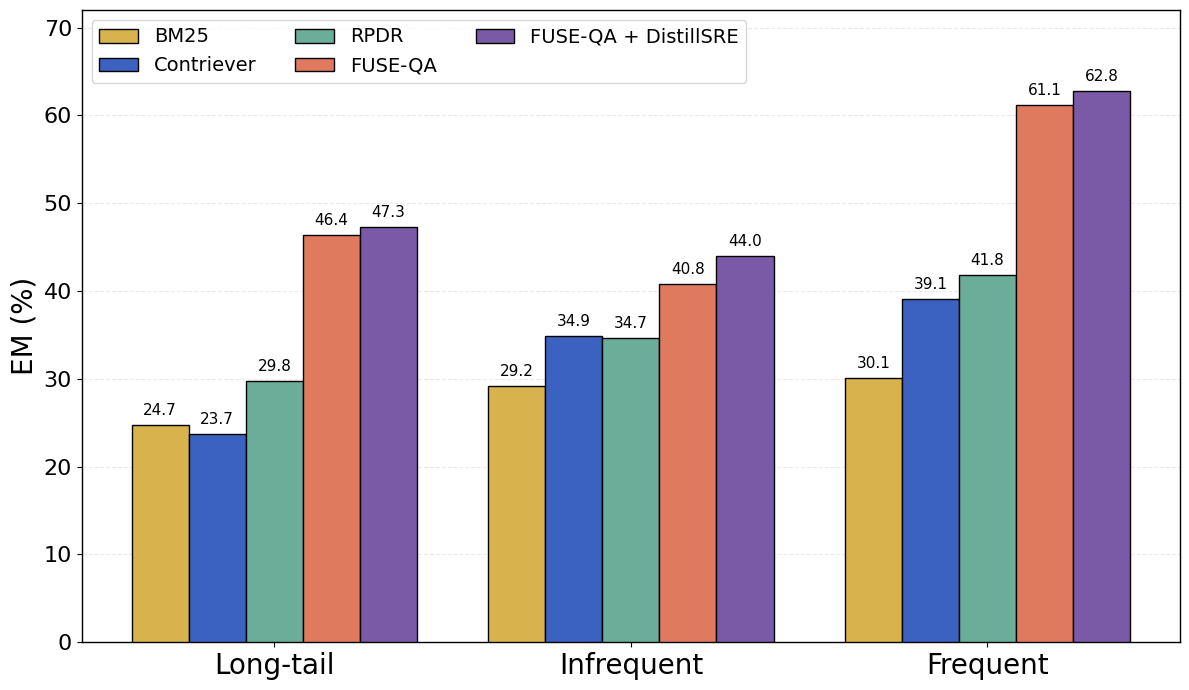

In [2]:
import matplotlib.pyplot as plt
import numpy as np

groups = ["Long-tail", "Infrequent", "Frequent"]

data = {
    "BM25": [24.70, 29.20, 30.10],
    "Contriever": [23.70, 34.90, 39.10],
    "RPDR": [29.80, 34.70, 41.80],
    "FUSE-QA": [46.39, 40.80, 61.14],
    "FUSE-QA + DistillSRE": [47.32, 43.96, 62.81],
}

colors = ["#D8B24C", "#3B62C0", "#6AAE9A", "#E07A5F", "#7A5AA6"]

x = np.arange(len(groups))
width = 0.16

fig, ax = plt.subplots(figsize=(12, 7))

for i, (label, values) in enumerate(data.items()):
    pos = x + (i - 2) * width
    bars = ax.bar(
        pos,
        values,
        width,
        label=label,
        color=colors[i],
        edgecolor="black",
        linewidth=1.0,
        zorder=3,
    )

    for j, b in enumerate(bars):
        ax.text(
            b.get_x() + b.get_width() / 2,
            b.get_height() + 0.8,
            f"{values[j]:.1f}",
            ha="center",
            va="bottom",
            fontsize=11,
        )

# Highlight your methods
for spine in ax.spines.values():
    spine.set_linewidth(1.0)

ax.set_ylabel("EM (%)", fontsize=20)
ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=20)
ax.tick_params(axis="y", labelsize=16)
ax.set_ylim(0, 72)

ax.legend(
    fontsize=14,
    ncol=3,
    loc="upper left",
    frameon=True
)

ax.grid(axis="y", linestyle="--", alpha=0.25, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

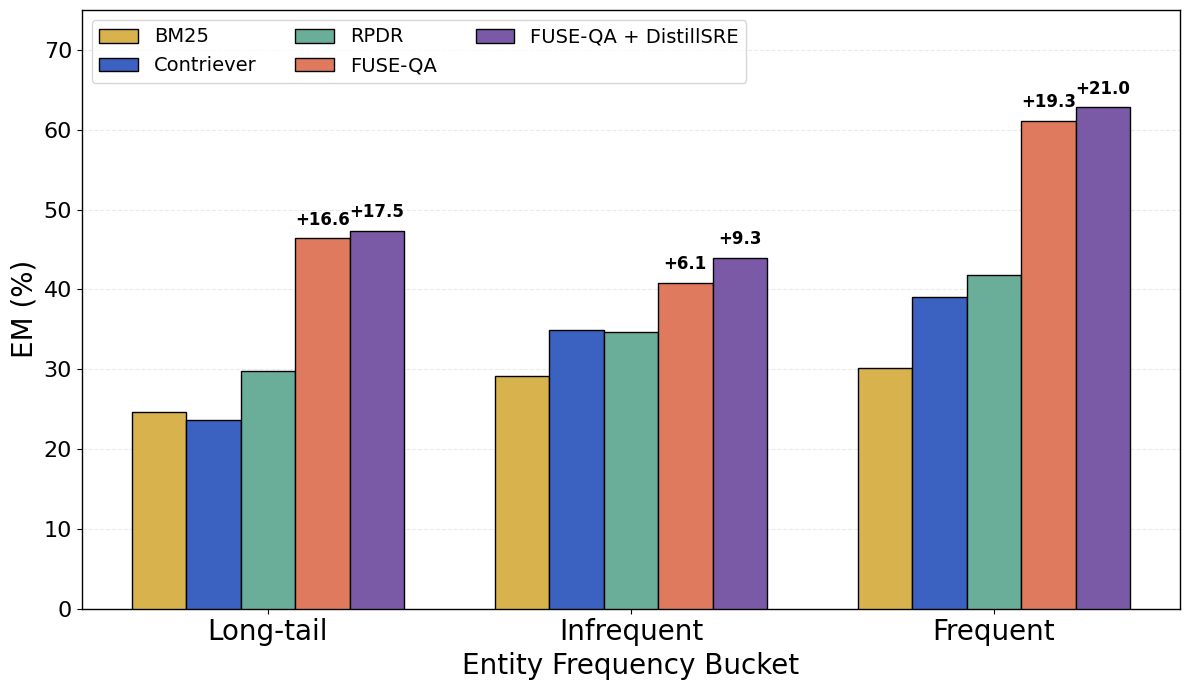

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Data from the paper
# PopQA / LLaMA-3 8B / EM (%)
# -----------------------------
groups = ["Long-tail", "Infrequent", "Frequent"]

data = {
    "BM25": [24.70, 29.20, 30.10],
    "Contriever": [23.70, 34.90, 39.10],
    "RPDR": [29.80, 34.70, 41.80],
    "FUSE-QA": [46.39, 40.80, 61.14],
    "FUSE-QA + DistillSRE": [47.32, 43.96, 62.81],
}

colors = {
    "BM25": "#D8B24C",
    "Contriever": "#3B62C0",
    "RPDR": "#6AAE9A",
    "FUSE-QA": "#E07A5F",
    "FUSE-QA + DistillSRE": "#7A5AA6",
}

x = np.arange(len(groups))
methods = list(data.keys())
n_methods = len(methods)
width = 0.15
offsets = np.linspace(-(n_methods - 1) / 2 * width, (n_methods - 1) / 2 * width, n_methods)

fig, ax = plt.subplots(figsize=(12, 7))

bar_containers = {}
for i, method in enumerate(methods):
    bars = ax.bar(
        x + offsets[i],
        data[method],
        width=width,
        label=method,
        color=colors[method],
        edgecolor="black",
        linewidth=1.0,
        zorder=3,
    )
    bar_containers[method] = bars

# -----------------------------
# Annotate gains over RPDR
# Only for FUSE-QA and FUSE-QA + DistillSRE
# -----------------------------
rpdr_vals = np.array(data["RPDR"])
fuse_vals = np.array(data["FUSE-QA"])
sre_vals = np.array(data["FUSE-QA + DistillSRE"])

fuse_gains = fuse_vals - rpdr_vals
sre_gains = sre_vals - rpdr_vals

# FUSE-QA annotations
for i, rect in enumerate(bar_containers["FUSE-QA"]):
    height = rect.get_height()
    gain = fuse_gains[i]
    ax.text(
        rect.get_x() + rect.get_width() / 2,
        height + 1.2,
        f"+{gain:.1f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        color="black",
    )

# FUSE-QA + DistillSRE annotations
for i, rect in enumerate(bar_containers["FUSE-QA + DistillSRE"]):
    height = rect.get_height()
    gain = sre_gains[i]
    ax.text(
        rect.get_x() + rect.get_width() / 2,
        height + 1.2,
        f"+{gain:.1f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        color="black",
    )

# -----------------------------
# Formatting
# -----------------------------
ax.set_ylabel("EM (%)", fontsize=20)
ax.set_xlabel("Entity Frequency Bucket", fontsize=20)
ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=20)
ax.tick_params(axis="y", labelsize=16)

ax.set_ylim(0, 75)

ax.legend(
    fontsize=14,
    ncol=3,
    loc="upper left",
    frameon=True,
)

ax.grid(axis="y", linestyle="--", alpha=0.25, zorder=0)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_linewidth(1.0)

plt.tight_layout()
plt.show()

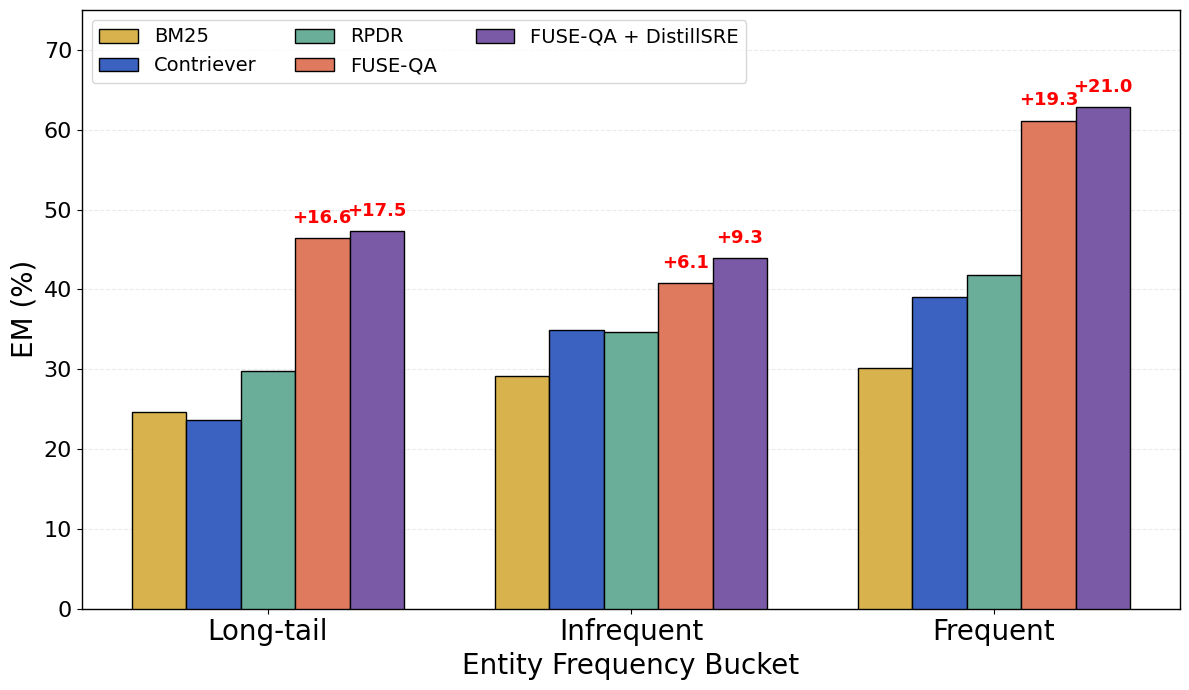

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Data from the paper
# PopQA / LLaMA-3 8B / EM (%)
# -----------------------------
groups = ["Long-tail", "Infrequent", "Frequent"]

data = {
    "BM25": [24.70, 29.20, 30.10],
    "Contriever": [23.70, 34.90, 39.10],
    "RPDR": [29.80, 34.70, 41.80],
    "FUSE-QA": [46.39, 40.80, 61.14],
    "FUSE-QA + DistillSRE": [47.32, 43.96, 62.81],
}

colors = {
    "BM25": "#D8B24C",
    "Contriever": "#3B62C0",
    "RPDR": "#6AAE9A",
    "FUSE-QA": "#E07A5F",
    "FUSE-QA + DistillSRE": "#7A5AA6",
}

x = np.arange(len(groups))
methods = list(data.keys())
n_methods = len(methods)
width = 0.15
offsets = np.linspace(-(n_methods - 1) / 2 * width, (n_methods - 1) / 2 * width, n_methods)

fig, ax = plt.subplots(figsize=(12, 7))

bar_containers = {}
for i, method in enumerate(methods):
    bars = ax.bar(
        x + offsets[i],
        data[method],
        width=width,
        label=method,
        color=colors[method],
        edgecolor="black",
        linewidth=1.0,
        zorder=3,
    )
    bar_containers[method] = bars

# -----------------------------
# Annotate gains over RPDR
# Only for FUSE-QA and FUSE-QA + DistillSRE
# -----------------------------
rpdr_vals = np.array(data["RPDR"])
fuse_vals = np.array(data["FUSE-QA"])
sre_vals = np.array(data["FUSE-QA + DistillSRE"])

fuse_gains = fuse_vals - rpdr_vals
sre_gains = sre_vals - rpdr_vals

# FUSE-QA annotations
for i, rect in enumerate(bar_containers["FUSE-QA"]):
    height = rect.get_height()
    gain = fuse_gains[i]
    ax.text(
        rect.get_x() + rect.get_width() / 2,
        height + 1.4,
        f"+{gain:.1f}",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
        color="red",
    )

# FUSE-QA + DistillSRE annotations
for i, rect in enumerate(bar_containers["FUSE-QA + DistillSRE"]):
    height = rect.get_height()
    gain = sre_gains[i]
    ax.text(
        rect.get_x() + rect.get_width() / 2,
        height + 1.4,
        f"+{gain:.1f}",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
        color="red",
    )

# -----------------------------
# Formatting
# -----------------------------
ax.set_ylabel("EM (%)", fontsize=20)
ax.set_xlabel("Entity Frequency Bucket", fontsize=20)
ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=20)
ax.tick_params(axis="y", labelsize=16)

ax.set_ylim(0, 75)

ax.legend(
    fontsize=14,
    ncol=3,
    loc="upper left",
    frameon=True,
)

ax.grid(axis="y", linestyle="--", alpha=0.25, zorder=0)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_linewidth(1.0)

plt.tight_layout()
plt.savefig("fuse_qa_teaser_barplot.png", dpi=400, bbox_inches="tight")
plt.savefig("fuse_qa_teaser_barplot.pdf", dpi=400, bbox_inches="tight")
plt.show()